<a href="https://colab.research.google.com/github/HootlingGondlier/Computational-Physics/blob/main/Stats_and_Bayesian6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install astroML

In [ ]:
!pip install tensorflow==2.16.1
!pip install tensorflow-probability==0.23.0
!pip install --upgrade tensorflow-probability
!pip install --upgrade tensorflow
!pip install --upgrade JAX

  Using cached tensorflow_probability-0.23.0-py2.py3-none-any.whl.metadata (13 kB)
Using cached tensorflow_probability-0.23.0-py2.py3-none-any.whl (6.9 MB)
  Attempting uninstall: tensorflow-probability
    Found existing installation: tensorflow-probability 0.25.0
    Uninstalling tensorflow-probability-0.25.0:
      Successfully uninstalled tensorflow-probability-0.25.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-probability
    Found existing installation: tensorflow-probability 0.23.0
    Uninstalling tensorflow-probability-0.23.0:
      Successfully uninstalled tensorflow-probability-0.23.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 20.2 MB/s eta 0:00:00
  Attempting u

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 55.5 MB/s eta 0:00:00
^C


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras
from keras import layers
import tensorflow_probability as tfp
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples, completeness_contamination


x, y = fetch_rrlyrae_combined()

tot = len(x)
RR = np.sum(y == 1)
N = np.sum(y == 0)

print(tot)
print(N, RR)


downloading cross-matched SDSS/2MASS dataset from https://github.com/astroML/astroML-data/raw/main/datasets/stripe82calibStars_v2.6.dat.gz to /root/astroML_data

uncompressing file...
93141
92658 483


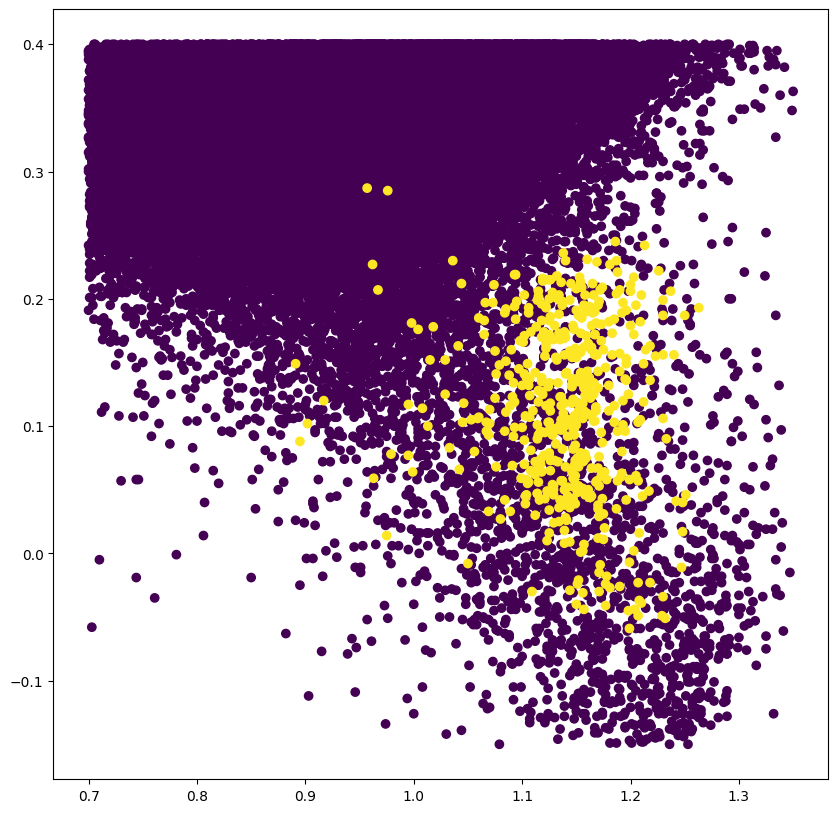

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()

In [ ]:
# The split_samples function returns ((x_train, x_test), (y_train, y_test))
(x_data, y_data) = split_samples(x, y, [0.7, 0.3], np.random.RandomState(0))
x_train, x_test = x_data
y_train, y_test = y_data

y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print(f'Shape of x_train: {x_train.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of x_test: {x_test.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of x_train: (65198, 4)
Shape of y_train: (65198,)
Shape of x_test: (27943, 4)
Shape of y_test: (27943,)


In [ ]:
input_dimensions = x_train.shape[1:]
print(input_dimensions)

(4,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.9944 - loss: 0.0203 - val_accuracy: 0.9946 - val_loss: 0.0133
Epoch 2/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9949 - loss: 0.0143 - val_accuracy: 0.9946 - val_loss: 0.0126
Epoch 3/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9949 - loss: 0.0136 - val_accuracy: 0.9946 - val_loss: 0.0113
Epoch 4/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9949 - loss: 0.0127 - val_accuracy: 0.9946 - val_loss: 0.0113
Epoch 5/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9949 - loss: 0.0120 - val_accuracy: 0.9946 - val_loss: 0.0123
Epoch 6/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9950 - loss: 0.0120 - val_accuracy: 0.9956 - val_loss: 0.0098
Epoch 7/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9948 - loss: 0.0114 - val_accuracy: 0.9948 - val_loss: 0.0113
Epoch 8/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9956 - loss: 

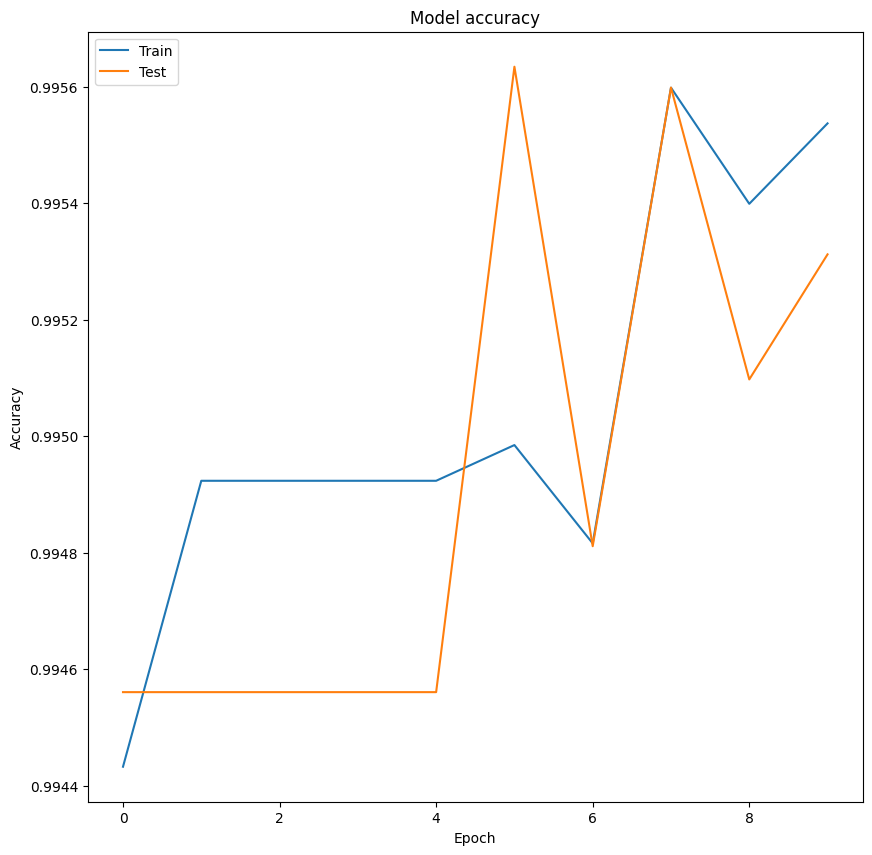

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(64, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(128, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(256, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(512, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
    ])
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs = 10,
          validation_data = (x_test, y_test))



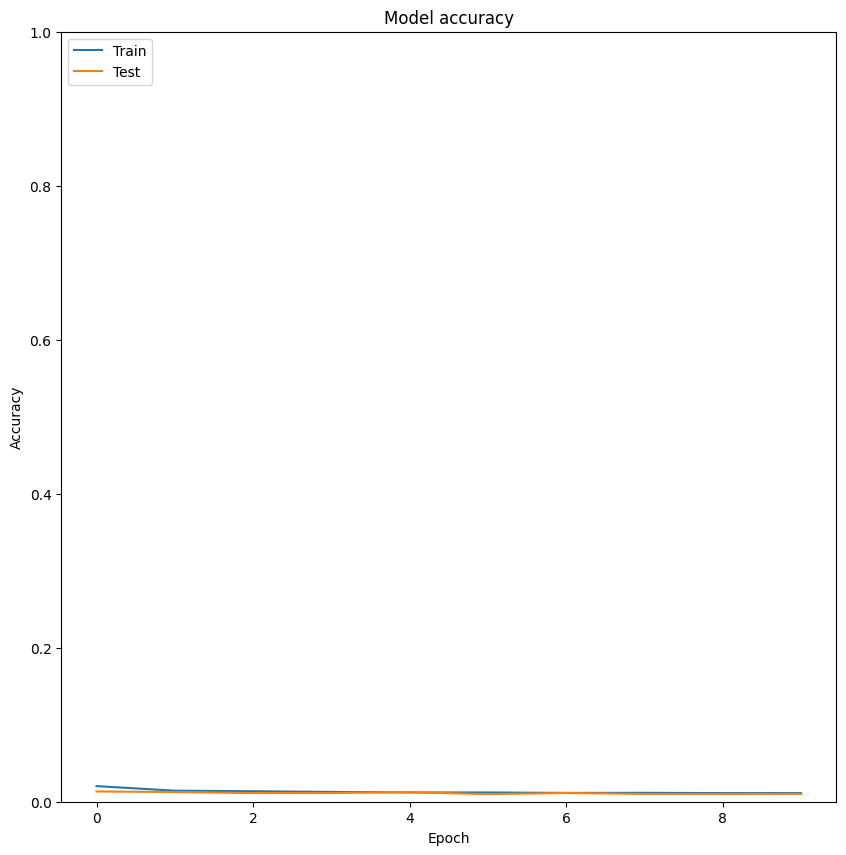

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.legend(['Train', 'Test'], loc='upper left')

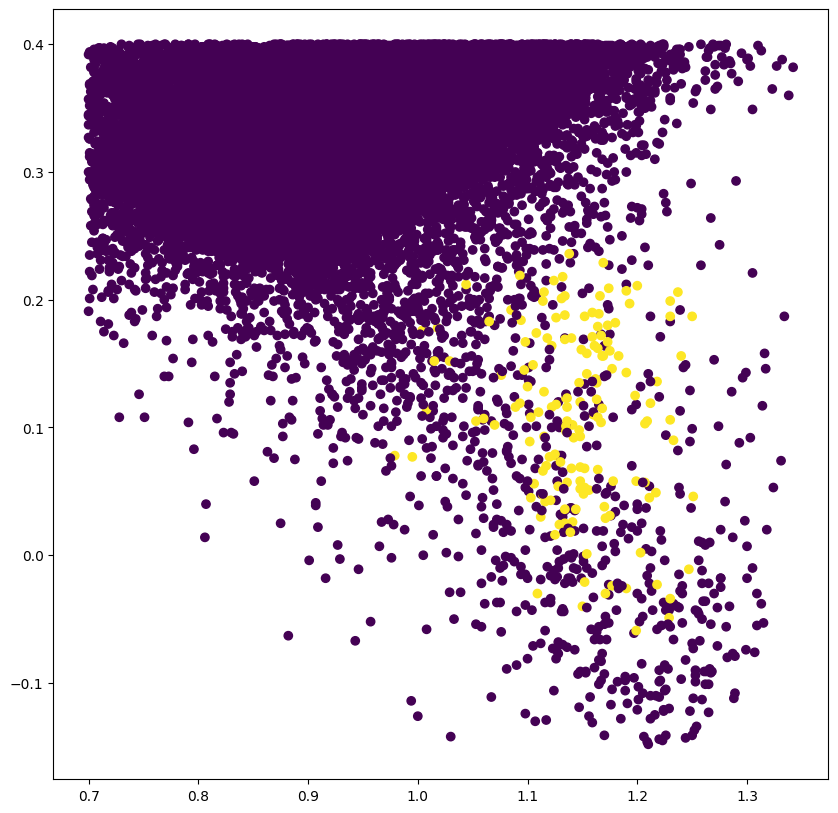

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
plt.show()

In [ ]:
random_layer = tf.keras.layers.Dense(
    128,
    activation='relu',
    kernel_initializer=tf.keras.initializers.RandomNormal(0.0, 0.05),
    trainable=False
)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_dimensions),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),

    random_layer,

    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10,
          validation_data=(x_test, y_test))

Epoch 1/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9944 - loss: 0.0219 - val_accuracy: 0.9946 - val_loss: 0.0175
Epoch 2/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9949 - loss: 0.0144 - val_accuracy: 0.9946 - val_loss: 0.0122
Epoch 3/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9949 - loss: 0.0132 - val_accuracy: 0.9946 - val_loss: 0.0113
Epoch 4/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9949 - loss: 0.0124 - val_accuracy: 0.9946 - val_loss: 0.0112
Epoch 5/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9949 - loss: 0.0122 - val_accuracy: 0.9946 - val_loss: 0.0142
Epoch 6/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9949 - loss: 0.0117 - val_accuracy: 0.9956 - val_loss: 0.0111
Epoch 7/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9953 - loss: 0.0116 - val_accuracy: 0.9958 - val_loss: 0.0102
Epoch 8/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9958 - loss: 0

In [ ]:
y_pred = model.predict(x_test)
print(y_pred)
y_pred_class = (y_pred > 0.5).astype(int)

874/874 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[1.7334648e-07]
 [2.3040745e-06]
 [8.3692690e-08]
 ...
 [9.5752739e-07]
 [1.3221361e-06]
 [6.9956572e-05]]


In [ ]:
predictions = []

for _ in range(100):
    pred = model(x_test, training=True)
    predictions.append(pred.numpy())

predictions = np.array(predictions)

In [ ]:
mean_prediction = predictions.mean(axis=0)
std_prediction = predictions.std(axis=0)
print(mean_prediction)
print(std_prediction)
print("RR Lyrae probability:",
      mean_prediction[0][0])

print("Uncertainty:",
      std_prediction[0][0])

[[1.7334625e-07]
 [2.3040766e-06]
 [8.3692640e-08]
 ...
 [9.5752830e-07]
 [1.3221355e-06]
 [6.9956637e-05]]
[[2.2737368e-13]
 [2.0463631e-12]
 [4.9737992e-14]
 ...
 [9.0949470e-13]
 [5.6843419e-13]
 [6.5483619e-11]]
RR Lyrae probability: 1.7334625e-07
Uncertainty: 2.2737368e-13


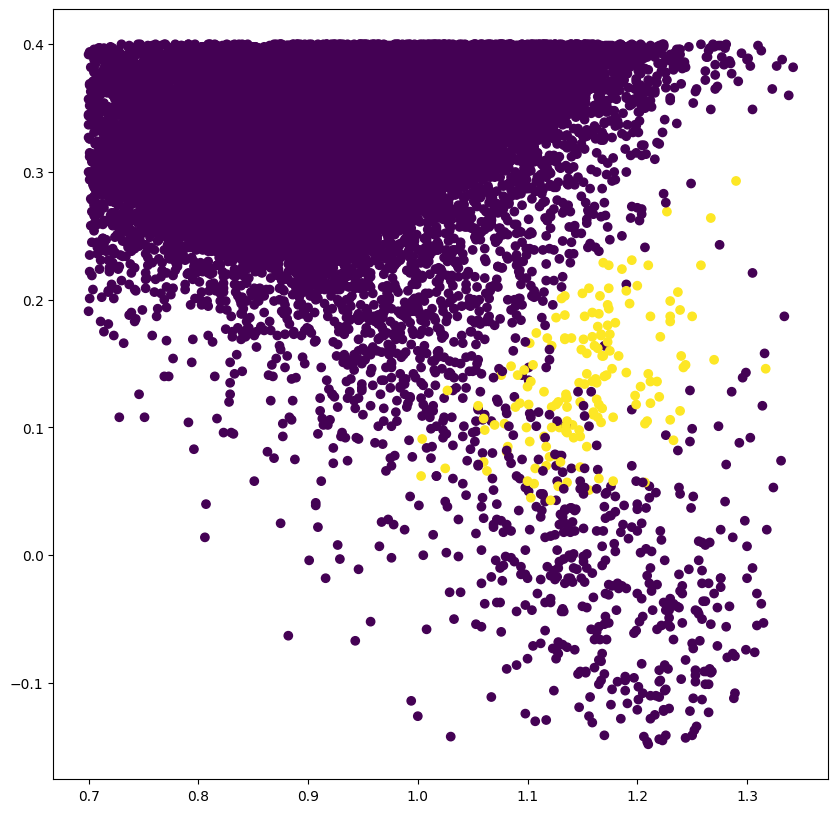

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_pred_class)
plt.show()

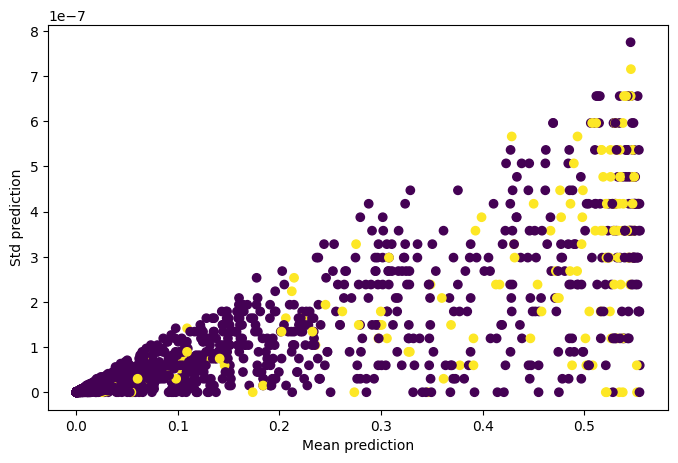

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(mean_prediction,
            std_prediction,
            c=y_test,)
plt.xlabel('Mean prediction')
plt.ylabel('Std prediction')
plt.show()


In [ ]:
class VariationalDense(tf.keras.layers.Layer):

    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):

        input_dim = input_shape[-1]

        self.w_mean = self.add_weight(
            shape=(input_dim, self.units),
            initializer="random_normal"
        )

        self.w_std = self.add_weight(
            shape=(input_dim, self.units),
            initializer="zeros"
        )

        self.b_mean = self.add_weight(
            shape=(self.units,),
            initializer="zeros"
        )

        self.b_std = self.add_weight(
            shape=(self.units,),
            initializer="zeros"
        )


    def call(self, inputs):

        w = self.w_mean + tf.random.normal(
            tf.shape(self.w_mean)
        ) * tf.nn.softplus(self.w_std)

        b = self.b_mean + tf.random.normal(
            tf.shape(self.b_mean)
        ) * tf.nn.softplus(self.b_std)

        output = tf.matmul(inputs,w) + b

        if self.activation:
            output = self.activation(output)

        return output

In [ ]:
tfd = tfp.distributions

def posterior_mean_field(kernel_size, bias_size=0, dtype=None):

    n = kernel_size + bias_size

    return tf.keras.Sequential([
        tfp.layers.VariableLayer(
            2*n,
            dtype=dtype
        ),
        tfp.layers.DistributionLambda(
            lambda t:
            tfd.Normal(
                loc=t[..., :n],
                scale=1e-5 + tf.nn.softplus(t[..., n:])
            )
        )
    ])

In [ ]:
# Prior distribution for weights
def prior_mean_field(kernel_size, bias_size=0, dtype=None):

    n = kernel_size + bias_size

    return tf.keras.Sequential([
        tfp.layers.DistributionLambda(
            lambda t: tfd.Normal(
                loc=tf.zeros(n),
                scale=1
            )
        )
    ])



In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(64, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(128, activation = 'relu', input_shape = input_dimensions),
    VariationalDense(256, activation='relu'),
    tf.keras.layers.Dense(512, activation = 'relu', input_shape = input_dimensions),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
    ])
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs = 10,
          validation_data = (x_test, y_test))

Epoch 1/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9949 - loss: 0.0204 - val_accuracy: 0.9946 - val_loss: 0.0165
Epoch 2/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9949 - loss: 0.0166 - val_accuracy: 0.9946 - val_loss: 0.0146
Epoch 3/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9949 - loss: 0.0146 - val_accuracy: 0.9946 - val_loss: 0.0134
Epoch 4/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9949 - loss: 0.0140 - val_accuracy: 0.9946 - val_loss: 0.0125
Epoch 5/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9949 - loss: 0.0132 - val_accuracy: 0.9948 - val_loss: 0.0115
Epoch 6/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9950 - loss: 0.0127 - val_accuracy: 0.9950 - val_loss: 0.0118
Epoch 7/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9948 - loss: 0.0129 - val_accuracy: 0.9949 - val_loss: 0.0108
Epoch 8/10
2038/2038 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9951 - loss: 0

In [ ]:
prediction = model.predict(x_test)
predictions = []

for _ in range(100):
    pred = model(x_test, training=True)
    predictions.append(pred.numpy())

predictions = np.array(predictions)

874/874 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
uncertainty = np.std(predictions, axis=0)
mean_prediction = np.mean(predictions, axis=0)
print(mean_prediction)
print(uncertainty)
print("RR Lyrae probability:",
      mean_prediction[0][0])

print("Uncertainty:",
      uncertainty[0][0])

[[1.9784361e-09]
 [2.2759610e-09]
 [2.0952155e-10]
 ...
 [2.0175270e-09]
 [5.7773453e-09]
 [1.9099049e-07]]
[[1.2156947e-08]
 [1.1514887e-08]
 [1.4518002e-09]
 ...
 [1.0987927e-08]
 [2.7317206e-08]
 [5.7099220e-07]]
RR Lyrae probability: 1.978436e-09
Uncertainty: 1.2156947e-08


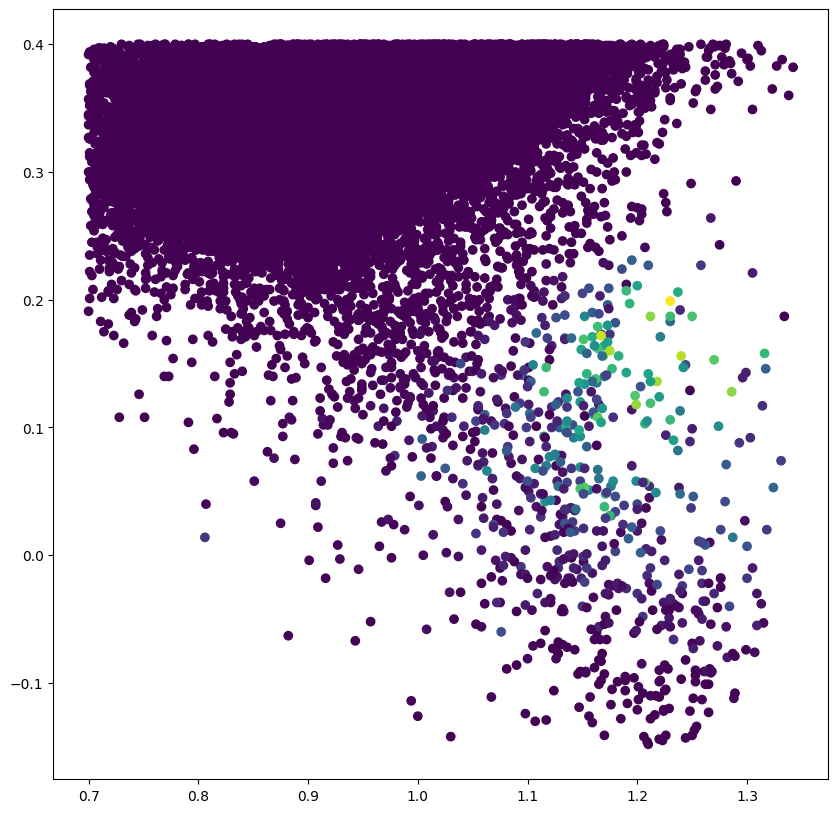

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(x_test[:, 0], x_test[:, 1], c = prediction)
plt.show()

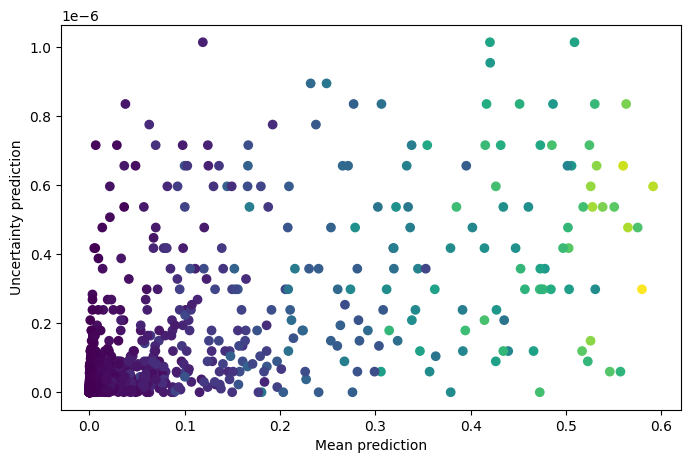

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(mean_prediction,
            std_prediction,
            c=prediction,)
plt.xlabel('Mean prediction')
plt.ylabel('Uncertainty prediction')
plt.show()